day 4-7

1- Setup and patching flash_attn_triton.py file to resolve compatibility issues with newer Triton versions

2- Loading the pre-trained DNABERT-2 model and implementing a custom DNAClassifier to adapt it for binary classification.

3- Baseline Performance

4- Data Preparation: diagnosis of the DNA sequence dataset, cleaning it, and splitting it into training, validation, and test sets.

5- Training Configuration & Fine-tuning using huggingFace Trainer

---------

1- Model evaluation (day 8)

2- Threshold Optimization (Day 9): Optimizing the classification threshold using the validation set to maximize performance metrics (specifically F1 score) and applying this optimized threshold to the test set predictions.

In [ ]:
# Mount Google Drive to save and load files
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted.')

Mounted at /content/drive
Google Drive mounted.


In [ ]:
# Triton must be installed BEFORE we ever import transformers or DNABERT-2.
# If transformers loads first, Python caches the broken flash_attn_triton.py
# in memory and patching the file on disk won't help
# the old code is
# already loaded. Order matters.

import subprocess, sys

subprocess.run([sys.executable, "-m", "pip", "install", "triton", "-q"], check=True)
print("✓ Triton installed")

✓ Triton installed


In [ ]:
# ═══════════════════════════════════════════════════════════════════
# FLASH ATTENTION PATCH — must run BEFORE importing DNABERT-2
# ═══════════════════════════════════════════════════════════════════
#
# WHY this error exists:
#   DNABERT-2 uses a custom Flash Attention kernel written in Triton.
#   It calls: tl.dot(q, k, trans_b=True)
#   But newer Triton removed the `trans_b` argument.
#   The correct modern syntax is: tl.dot(q, tl.trans(k))
#
# WHY the patch must happen here (before model load):
#   When you call AutoModel.from_pretrained() or snapshot_download(),
#   HuggingFace copies flash_attn_triton.py into a local cache at:
#       ~/.cache/huggingface/modules/transformers_modules/...
#   Then Python imports it. Once imported, patching the file on disk
#   does nothing — Python already has the old code in memory.
#   So we patch AFTER the file is written (by downloading the model)
#   but BEFORE Python imports it (before any model loading code runs).
#
# THREE LAYERS that all need clearing:
#   1. The .py source file in HuggingFace's module cache
#   2. Triton's compiled binary cache (~/.triton/cache)
#   3. Python's in-memory module cache (sys.modules)

import os, glob, shutil, sys

# Step 1: Download only the config/tokenizer so HuggingFace writes
# the custom code files to disk — but don't load the model yet.
from huggingface_hub import snapshot_download
model_path = snapshot_download("zhihan1996/DNABERT-2-117M")
print(f"✓ Model files at: {model_path}")

# Step 2: Find and patch flash_attn_triton.py
matches = glob.glob(
    "/root/.cache/huggingface/modules/transformers_modules/**/flash_attn_triton.py",
    recursive=True
)
print(f"\nFound {len(matches)} flash_attn_triton.py file(s):")

if not matches:
    print("  ⚠ File not found yet — this is OK if the model hasn't been downloaded.")
    print("  Re-run this cell after running the snapshot_download line above.")
else:
    for filepath in matches:
        with open(filepath, 'r') as f:
            source = f.read()

        if 'trans_b=True' in source:
            # The correct fix: replace the removed argument with tl.trans()
            # tl.trans(k) transposes the matrix k — same math, new API
            patched = source.replace(
                'tl.dot(q, k, trans_b=True)',
                'tl.dot(q, tl.trans(k))'
            )
            with open(filepath, 'w') as f:
                f.write(patched)
            print(f"  ✓ Patched: {filepath}")
        else:
            print(f"  ✓ Already patched: {filepath}")

# Step 3: Delete Triton's compiled binary cache
# WHY: Triton compiles .py kernels → .cubin GPU binaries and caches them.
# Even after fixing the source, if the cache has an old binary,
# that binary runs instead. We delete it so Triton recompiles from
# our patched source.
triton_cache = os.path.expanduser("~/.triton/cache")
if os.path.exists(triton_cache):
    shutil.rmtree(triton_cache)
    print(f"\n✓ Triton binary cache deleted: {triton_cache}")
else:
    print(f"\n✓ No Triton cache found (nothing to clear)")

# Step 4: Clear Python's in-memory module cache for anything DNABERT/flash/triton related
# WHY: sys.modules holds every imported module. If any flash_attn code was imported
# before this patch ran, those old module objects would still be used even though
# we patched the file. Removing them forces Python to re-import from disk.
keys_to_remove = [k for k in sys.modules if any(
    x in k.lower() for x in ['flash_attn', 'bert', 'triton', 'transformers_modules']
)]
for k in keys_to_remove:
    del sys.modules[k]
print(f"✓ Cleared {len(keys_to_remove)} cached module(s) from memory")

print("\n" + "="*50)
print("Flash Attention is now patched at all three layers.")
print("Proceed directly to Cell 1 — no restart needed.")
print("="*50)

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

✓ Model files at: /root/.cache/huggingface/hub/models--zhihan1996--DNABERT-2-117M/snapshots/7bce263b15377fc15361f52cfab88f8b586abda0

Found 0 flash_attn_triton.py file(s):
  ⚠ File not found yet — this is OK if the model hasn't been downloaded.
  Re-run this cell after running the snapshot_download line above.

✓ No Triton cache found (nothing to clear)
✓ Cleared 0 cached module(s) from memory

Flash Attention is now patched at all three layers.
Proceed directly to Cell 1 — no restart needed.


DNA looks like plain text to us (ATCG...), but the model has never seen raw letters because it was trained on tokens (short chunks of sequence).

DNABERT-2 uses a special tokenizer that was pre-trained on DNA, so it knows that ATG (start codon) is a meaningful unit. So it would be pointless to throw away that structure by feeding it raw characters.


PyTorch needs Dataset class:
1- a class with a __len__ method (how many examples?) and
2- a __getitem__ method (give me example #N).

This wrapper lets the DataLoader shuffle, batch, and parallel-load your data automatically.

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# CELL 1: Load DNABERT-2 and build DNAClassifier
# ═══════════════════════════════════════════════════════════════════
#
# WHY a two-step load (config → weights) instead of from_pretrained()?
#   AutoModelForSequenceClassification.from_pretrained() triggers a
#   meta-device error with DNABERT-2's custom initialization code.
#   Loading in two steps — build the architecture first from config,
#   then load the weights manually — bypasses that bug entirely.

import sys, os, torch, torch.nn as nn
from transformers import AutoConfig, AutoModel, AutoTokenizer
import transformers.utils

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# model_path was set in Cell 0B — it's the local HuggingFace cache path
print(f"Loading from: {model_path}")

# ── Fix: patch the import scanner in newer transformers versions ──────
# WHY: transformers moved import_utils into a submodule, but the dynamic
# module loader still looks for it at transformers.utils.import_utils.
# We add it back so the attribute lookup doesn't crash on import.
if not hasattr(transformers.utils, 'import_utils'):
    from transformers.utils import import_utils
    transformers.utils.import_utils = import_utils
    print("✓ Patched transformers.utils.import_utils")

# Step 1: Load and configure the model config
config = AutoConfig.from_pretrained(model_path, trust_remote_code=True)
config.num_labels = 2
config.pad_token_id = 3          # DNABERT-2 doesn't set this by default; 3 = [PAD]
config.problem_type = "single_label_classification"
config.classifier_dropout = None
if hasattr(config, 'use_flash_attn'):
    config.use_flash_attn = torch.cuda.is_available() # Enable Flash Attention only if CUDA is available
print("✓ Config loaded and patched")

# Step 2: Build the backbone architecture from config (no weights yet)
# WHY set_default_device("cpu")? Prevents PyTorch from allocating tensors
# on the GPU during model construction, which can cause meta-device errors.
torch.set_default_device("cpu")
backbone = AutoModel.from_config(config, trust_remote_code=True)

# Step 3: Load the pre-trained weights manually
state_dict = torch.load(
    os.path.join(model_path, "pytorch_model.bin"),
    map_location="cpu"
)

# Step 4: Strip the 'bert.' prefix that exists in the saved weights
# WHY: DNABERT-2's saved weights have keys like 'bert.encoder.layer.0...'
# but our backbone object expects 'encoder.layer.0...'
# We also skip 'cls.predictions' — those are MLM head weights we don't need.
new_state_dict = {}
for k, v in state_dict.items():
    new_k = k[len('bert.'):] if k.startswith('bert.') else k
    if not new_k.startswith('cls.predictions'):
        new_state_dict[new_k] = v

backbone.load_state_dict(new_state_dict, strict=False)
backbone = backbone.to(device)
print(f"✓ Backbone loaded")

# Step 5: Define the classification wrapper
# WHY a wrapper class instead of adding a head directly?
#   It keeps the code modular — the backbone is unchanged, and we can
#   swap it out or inspect it independently. The classifier head is just
#   a small MLP on top of the [CLS] token's hidden state.

class DNAClassifier(nn.Module):
    def __init__(self, backbone, num_labels=2):
        super().__init__()
        self.backbone = backbone
        hidden_size = backbone.config.hidden_size  # 768 for DNABERT-2-117M
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Dropout(0.1),
            nn.Linear(hidden_size, num_labels)
        )
        self.num_labels = num_labels

    def forward(self, input_ids, attention_mask=None, labels=None, **kwargs):
        # **kwargs absorbs extra fields like token_type_ids that the
        # tokenizer returns but we don't use — avoids silent crashes.
        outputs = self.backbone(input_ids=input_ids, attention_mask=attention_mask)

        # DNABERT-2 can return either a tuple or a HuggingFace output object
        # depending on version. This handles both.
        if hasattr(outputs, 'last_hidden_state'):
            hidden = outputs.last_hidden_state
        else:
            hidden = outputs[0]

        # [CLS] token (position 0) is the model's summary of the whole sequence
        cls_output = hidden[:, 0, :]
        logits = self.classifier(cls_output)

        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)

        from transformers.modeling_outputs import SequenceClassifierOutput
        return SequenceClassifierOutput(loss=loss, logits=logits)

# Step 6: Build the full model and move to GPU
model = DNAClassifier(backbone, num_labels=2).to(device)
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f"✓ Model ready — {total_params:,} parameters")
print(f"\nReady for baseline inference (Cell 2).")


Using device: cuda
Loading from: /root/.cache/huggingface/hub/models--zhihan1996--DNABERT-2-117M/snapshots/7bce263b15377fc15361f52cfab88f8b586abda0
✓ Config loaded and patched


/root/.cache/huggingface/modules/transformers_modules/_7bce263b15377fc15361f52cfab88f8b586abda0/bert_layers.py:126: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


✓ Backbone loaded
✓ Model ready — 117,660,674 parameters

Ready for baseline inference (Cell 2).


In [ ]:
# ═══════════════════════════════════════════════════════════════════
# CELL 2: Baseline Inference
# ═══════════════════════════════════════════════════════════════════
#
# WHY run inference BEFORE training?
#   This is your "before photo." An untrained model is essentially
#   guessing — you expect ~40–60% accuracy and F1 near 0.
#   Recording this baseline makes your final results meaningful.
#   A val F1 of 0.783 means nothing without knowing where you started.

tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
print("✓ Tokenizer loaded")

sample_seqs = [
    "ATGCGATCGATCGTAGCTAGCTAGCTAGCTATCGATCG",
    "GCTAGCTAGCTAGCTATCGATCGATCGATCGATCGATCG",
    "ATGATGATGATGATGATGATGATGATGATGATGATGATG",
    "CGATCGATCGATCGATCGATCGATCGATCGATCGATCG",
    "TTAGGGTTAGGGTTAGGGTTAGGGTTAGGGTTAGGGT",
]
sample_labels = [0, 1, 0, 1, 0]

# Tokenize: convert raw DNA characters → integer token IDs the model understands
# max_length=200 based on data diagnosis: our sequences are ~105 tokens,
# so 200 gives headroom without the 80% padding waste of the default 512.
inputs = tokenizer(
    sample_seqs,
    return_tensors="pt",
    padding="max_length",
    max_length=200,
    truncation=True
).to(device)

# torch.no_grad() disables gradient tracking — we're not training here,
# so we don't need the computation graph. Saves memory and runs faster.
with torch.no_grad():
    outputs = model(**inputs)

predictions = outputs.logits.argmax(dim=-1).tolist()

print("\n" + "=" * 40)
print("BASELINE (before any fine-tuning)")
print("=" * 40)
print(f"{'Seq':<6} {'True':>6} {'Pred':>6} {'Correct':>8}")
print("-" * 40)
for i, (true, pred) in enumerate(zip(sample_labels, predictions)):
    correct = "✓" if true == pred else "✗"
    print(f"  {i+1:<4} {true:>6} {pred:>6} {correct:>8}")

accuracy = sum(p == l for p, l in zip(predictions, sample_labels)) / len(sample_labels)
print("-" * 40)
print(f"Baseline accuracy: {accuracy:.0%}")
print("\nRecord this number — it is your 'before' photo.")
print("If Flash Attention is working, you'll see no errors above.")

✓ Tokenizer loaded

BASELINE (before any fine-tuning)
Seq      True   Pred  Correct
----------------------------------------
  1         0      0        ✓
  2         1      0        ✗
  3         0      1        ✗
  4         1      1        ✓
  5         0      0        ✓
----------------------------------------
Baseline accuracy: 60%

Record this number — it is your 'before' photo.
If Flash Attention is working, you'll see no errors above.


# Fix trans_b

In [ ]:
import glob

matches = glob.glob(
    "/root/.cache/huggingface/modules/transformers_modules/**/flash_attn_triton.py",
    recursive=True
)
for f in matches:
    content = open(f).read()
    count = content.count('trans_b=True')
    print(f"File: {f}")
    print(f"  trans_b=True occurrences remaining: {count}")

File: /root/.cache/huggingface/modules/transformers_modules/_7bce263b15377fc15361f52cfab88f8b586abda0/flash_attn_triton.py
  trans_b=True occurrences remaining: 3


In [ ]:
import glob, re, os, shutil, sys

TARGET = "/root/.cache/huggingface/modules/transformers_modules/_7bce263b15377fc15361f52cfab88f8b586abda0/flash_attn_triton.py"

with open(TARGET, 'r') as f:
    source = f.read()

print(f"File length: {len(source)} chars")
print(f"Occurrences of 'trans_b': {source.count('trans_b')}")

# Show the exact lines containing trans_b so we can see the real string
for i, line in enumerate(source.splitlines()):
    if 'trans_b' in line:
        print(f"  Line {i+1}: {repr(line)}")

File length: 42737 chars
Occurrences of 'trans_b': 3
  Line 191: '        qk += tl.dot(q, k, trans_b=True)'
  Line 434: '        qk = tl.dot(q, k, trans_b=True)'
  Line 501: '        dp = tl.dot(do, v, trans_b=True)'


In [ ]:
import os, shutil, sys

TARGET = "/root/.cache/huggingface/modules/transformers_modules/_7bce263b15377fc15361f52cfab88f8b586abda0/flash_attn_triton.py"

with open(TARGET, 'r') as f:
    source = f.read()

# Fix all 3 occurrences with their exact strings (copied from repr output)
patched = source.replace(
    'tl.dot(q, k, trans_b=True)',
    'tl.dot(q, tl.trans(k))'
).replace(
    'tl.dot(do, v, trans_b=True)',
    'tl.dot(do, tl.trans(v))'
)

remaining = patched.count('trans_b')
if remaining == 0:
    with open(TARGET, 'w') as f:
        f.write(patched)
    print("✓ All 3 occurrences patched and saved")
else:
    print(f"⚠ {remaining} occurrence(s) still remaining — do not save")

# Clear Triton's compiled binary cache
shutil.rmtree(os.path.expanduser("~/.triton/cache"), ignore_errors=True)
print("✓ Triton binary cache cleared")

# Clear in-memory module cache
removed = [k for k in sys.modules if any(
    x in k.lower() for x in ['flash_attn', 'triton', 'transformers_modules', 'bert']
)]
for k in removed:
    del sys.modules[k]
print(f"✓ Cleared {len(removed)} cached modules")

print("\nNow re-run Cell 1 (model load) and Cell 2 (inference) — no restart needed.")

✓ All 3 occurrences patched and saved
✓ Triton binary cache cleared
✓ Cleared 123 cached modules

Now re-run Cell 1 (model load) and Cell 2 (inference) — no restart needed.


# **FIXED!**

Cell 3 — Data diagnosis

In [ ]:
import pandas as pd, numpy as np, re

df = pd.read_csv("sequences_dataset.csv")

print("=" * 45)
print("DATA DIAGNOSIS")
print("=" * 45)

# Class balance
counts = df['label'].value_counts()
total = len(df)
print(f"\n1. Class balance:")
print(f"   Label 0: {counts[0]:>5} ({counts[0]/total:.1%})")
print(f"   Label 1: {counts[1]:>5} ({counts[1]/total:.1%})")
ratio = counts.min() / counts.max()
print(f"   {'✓ Balanced' if ratio >= 0.4 else '⚠ Imbalanced'} (ratio: {ratio:.2f})")

# Sequence character lengths
df['seq_len'] = df['sequence'].str.len()
print(f"\n2. Character lengths: min={df['seq_len'].min()} max={df['seq_len'].max()} mean={df['seq_len'].mean():.0f}")

# Real token lengths (what the model actually sees)
sample_seqs = df['sequence'].sample(200, random_state=42).tolist()
token_lengths = sorted([
    len(tokenizer(s, padding=False, truncation=False)['input_ids'])
    for s in sample_seqs
])
p95 = token_lengths[int(len(token_lengths) * 0.95)]
median = token_lengths[len(token_lengths) // 2]
print(f"\n3. Token lengths (sample of 200):")
print(f"   min={min(token_lengths)} max={max(token_lengths)} median={median} p95={p95}")
print(f"   Recommended max_length: {p95 + 10}")
print(f"   Default 512 wasted {512 - median} slots per sequence on padding")

# Data quality
non_acgt = df['sequence'].str.contains(r'[^ACGTacgt]', regex=True).sum()
print(f"\n4. Data quality:")
print(f"   NaN labels: {df['label'].isna().sum()}")
print(f"   Non-ACGT sequences: {non_acgt} {'← will be removed' if non_acgt > 0 else ''}")

DATA DIAGNOSIS

1. Class balance:
   Label 0:  4996 (50.0%)
   Label 1:  4999 (50.0%)
   ✓ Balanced (ratio: 1.00)

2. Character lengths: min=513 max=513 mean=513

3. Token lengths (sample of 200):
   min=95 max=117 median=104 p95=111
   Recommended max_length: 121
   Default 512 wasted 408 slots per sequence on padding

4. Data quality:
   NaN labels: 0
   Non-ACGT sequences: 1 ← will be removed


Cell 4 — Data preparation

In [ ]:
from sklearn.model_selection import train_test_split

# Remove non-ACGT sequences
mask = df['sequence'].str.contains(r'[^ACGTacgt]', regex=True)
df_clean = df[~mask].reset_index(drop=True)
print(f"Removed {mask.sum()} bad sequence(s). Remaining: {len(df_clean)}")

# stratify= ensures each split has the same class ratio
train_df, temp_df = train_test_split(
    df_clean, test_size=0.2, random_state=42, stratify=df_clean['label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df['label']
)

test_df.to_csv("test_set.csv", index=False)  # locked away until Day 8

print(f"\nSplit sizes:")
print(f"  Train: {len(train_df):>5}  ({train_df['label'].mean():.1%} positive)")
print(f"  Val:   {len(val_df):>5}  ({val_df['label'].mean():.1%} positive)")
print(f"  Test:  {len(test_df):>5}  ({test_df['label'].mean():.1%} positive) ← do not touch until Day 8")

Removed 1 bad sequence(s). Remaining: 9994

Split sizes:
  Train:  7995  (50.0% positive)
  Val:     999  (50.1% positive)
  Test:   1000  (50.0% positive) ← do not touch until Day 8


Cell 5 — Dataset and DataLoader

In [ ]:
from torch.utils.data import Dataset

REAL_MAX_LENGTH = 200  # based on diagnosis: p95 token length ~112, +10 buffer

class DNADataset(Dataset):
    def __init__(self, sequences, labels, tokenizer, max_length=200):
        self.sequences = sequences
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        encoded = self.tokenizer(
            self.sequences[idx],
            return_tensors="pt",
            padding="max_length",
            max_length=self.max_length,
            truncation=True
        )
        return {
            "input_ids":      encoded["input_ids"].squeeze(0),      # [1,L] → [L]
            "attention_mask": encoded["attention_mask"].squeeze(0),  # [1,L] → [L]
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long)
        }


train_dataset = DNADataset(
    train_df['sequence'].tolist(), train_df['label'].tolist(),
    tokenizer, max_length=REAL_MAX_LENGTH
)
val_dataset = DNADataset(
    val_df['sequence'].tolist(), val_df['label'].tolist(),
    tokenizer, max_length=REAL_MAX_LENGTH
)

# Sanity check — verify shapes before touching the Trainer
sample = train_dataset[0]
real_tokens = (sample['attention_mask'] == 1).sum().item()
print(f"input_ids shape:      {sample['input_ids'].shape}")       # → [200]
print(f"attention_mask shape: {sample['attention_mask'].shape}")  # → [200]
print(f"Real tokens: {real_tokens}  Padding: {REAL_MAX_LENGTH - real_tokens}")
print(f"\nTrain: {len(train_dataset):,} sequences")
print(f"Val:   {len(val_dataset):,} sequences")

input_ids shape:      torch.Size([200])
attention_mask shape: torch.Size([200])
Real tokens: 104  Padding: 96

Train: 7,995 sequences
Val:   999 sequences


Cell 6 — Training configuration

In [ ]:
from transformers import TrainingArguments, Trainer, TrainerCallback
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1":       f1_score(labels, predictions, average='binary')
    }

training_args = TrainingArguments(
    output_dir="./dnabert2-finetuned",
    num_train_epochs=5,
    per_device_train_batch_size=16,  # increased: shorter seqs fit more per batch
    per_device_eval_batch_size=32,
    learning_rate=5e-5,              # increased from 2e-5 — was learning too slowly
    warmup_ratio=0.06,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,     # restores the best checkpoint when done
    metric_for_best_model="f1",      # F1 is more robust than accuracy for binary tasks
    greater_is_better=True,
    logging_steps=50,
    fp16=True,                       # ~2x faster, ~2x less VRAM — free speedup on T4
    report_to="none",
    dataloader_num_workers=2,
)

class PrintMetricsCallback(TrainerCallback):
    """Prints training loss every 50 steps and val metrics after each epoch."""
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and 'loss' in logs:
            print(f"  Step {state.global_step:>4}/{state.max_steps} "
                  f"| loss: {logs['loss']:.4f} "
                  f"| lr: {logs.get('learning_rate', 0):.2e}")

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics:
            print()
            print(f"  ┌─ Epoch {int(state.epoch)} evaluation ─────────────────")
            print(f"  │  val loss:     {metrics.get('eval_loss', 0):.4f}")
            print(f"  │  val accuracy: {metrics.get('eval_accuracy', 0):.4f}")
            print(f"  │  val F1:       {metrics.get('eval_f1', 0):.4f}")
            print(f"  └────────────────────────────────────────")
            print()

print("Training configuration ready")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training configuration ready


Cell 7 — Fine-tuning
Trains for 5 epochs. load_best_model_at_end=True automatically restores the best checkpoint. Based on previous results, expect best performance at epoch 3 (overfitting begins at epoch 4).

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# CELL 7: Fine-tuning
# ═══════════════════════════════════════════════════════════════════
#
# WHY a custom DNATrainer instead of the standard Trainer?
#   HuggingFace's Trainer.save_model() calls model.save_pretrained(),
#   which only works on native HuggingFace models. Our DNAClassifier
#   is a custom nn.Module wrapper, so save_pretrained() would crash.
#   We override save_model() to use torch.save() instead — saving the
#   raw state_dict (the weights dictionary) directly to disk.
#
# WHY load_best_model_at_end=True?
#   Training for 5 epochs doesn't mean epoch 5 is the best.
#   From previous runs we know overfitting starts at epoch 4.
#   This setting makes the Trainer automatically restore the epoch 3
#   checkpoint (the best val F1) when training finishes.

# Build a FRESH backbone for training — separate from the baseline model
# WHY fresh? The baseline model in Cell 1 was used for inference already.
# We want training to start from clean pretrained weights, not weights
# that may have been subtly affected by the forward pass.
backbone_train = AutoModel.from_config(config, trust_remote_code=True)

state_dict = torch.load(
    os.path.join(model_path, "pytorch_model.bin"), map_location="cpu"
)
new_state_dict = {}
for k, v in state_dict.items():
    new_k = k[len('bert.'):] if k.startswith('bert.') else k
    if not new_k.startswith('cls.predictions'):
        new_state_dict[new_k] = v

backbone_train.load_state_dict(new_state_dict, strict=False)
backbone_train = backbone_train.to(device)

model_train = DNAClassifier(backbone_train, num_labels=2).to(device)
print(f"✓ Fresh training model: {sum(p.numel() for p in model_train.parameters()):,} parameters")

# Quick sanity check — one forward pass before committing to full training
# WHY? Catches shape mismatches or attention errors immediately,
# before wasting 20 minutes only to crash at step 1.
_t = tokenizer("ATCGATCGATCG", return_tensors="pt",
               max_length=200, truncation=True, padding="max_length")
_t = {k: v.to(device) for k, v in _t.items()}
with torch.no_grad():
    _out = model_train(**_t)
print(f"✓ Sanity check passed — logits: {_out.logits}")

# Custom Trainer: only change is save_model()
class DNATrainer(Trainer):
    def save_model(self, output_dir=None, _internal_call=False):
        output_dir = output_dir or self.args.output_dir
        os.makedirs(output_dir, exist_ok=True)
        torch.save(self.model.state_dict(), os.path.join(output_dir, "dna_classifier.pt"))
        tokenizer.save_pretrained(output_dir)

trainer = DNATrainer(
    model=model_train,
    args=training_args,           # defined in Cell 6
    train_dataset=train_dataset,  # defined in Cell 5
    eval_dataset=val_dataset,     # defined in Cell 5
    compute_metrics=compute_metrics,
)
trainer.add_callback(PrintMetricsCallback())

print(f"\nStarting fine-tuning...")
print(f"  Epochs:     {training_args.num_train_epochs}")
print(f"  Batch size: {training_args.per_device_train_batch_size}")
print(f"  LR:         {training_args.learning_rate}")
print(f"  Steps/epoch:{len(train_dataset) // training_args.per_device_train_batch_size}")
print(f"  fp16:       {training_args.fp16}")
print()

trainer.train()

print("\n" + "="*45)
print("FINE-TUNING COMPLETE")
print("="*45)
print("load_best_model_at_end=True has restored the best checkpoint.")
print("Check the val F1 values printed above — the highest one is what you have.")
print("Proceed to Cell 8 to save the model.")

/root/.cache/huggingface/modules/transformers_modules/_7bce263b15377fc15361f52cfab88f8b586abda0/bert_layers.py:126: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


✓ Fresh training model: 117,660,674 parameters
✓ Sanity check passed — logits: tensor([[-0.2150, -0.0339]], device='cuda:0')

Starting fine-tuning...
  Epochs:     5
  Batch size: 16
  LR:         5e-05
  Steps/epoch:499
  fp16:       True



Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.595565,0.564976,0.710711,0.736554
2,0.455425,0.546952,0.739740,0.775087
3,0.334755,0.684317,0.734735,0.768963
4,0.140245,0.889766,0.743744,0.748031
5,0.097551,1.109082,0.760761,0.771292


  Step   50/2500 | loss: 0.6923 | lr: 1.63e-05
  Step  100/2500 | loss: 0.6681 | lr: 3.30e-05
  Step  150/2500 | loss: 0.6417 | lr: 4.97e-05
  Step  200/2500 | loss: 0.6543 | lr: 4.90e-05
  Step  250/2500 | loss: 0.6727 | lr: 4.79e-05
  Step  300/2500 | loss: 0.6394 | lr: 4.68e-05
  Step  350/2500 | loss: 0.6052 | lr: 4.58e-05
  Step  400/2500 | loss: 0.6060 | lr: 4.47e-05
  Step  450/2500 | loss: 0.6295 | lr: 4.36e-05
  Step  500/2500 | loss: 0.5956 | lr: 4.26e-05

  ┌─ Epoch 1 evaluation ─────────────────
  │  val loss:     0.5650
  │  val accuracy: 0.7107
  │  val F1:       0.7366
  └────────────────────────────────────────

  Step  550/2500 | loss: 0.5411 | lr: 4.15e-05
  Step  600/2500 | loss: 0.5242 | lr: 4.04e-05
  Step  650/2500 | loss: 0.5006 | lr: 3.94e-05
  Step  700/2500 | loss: 0.5008 | lr: 3.83e-05
  Step  750/2500 | loss: 0.5298 | lr: 3.73e-05
  Step  800/2500 | loss: 0.5171 | lr: 3.62e-05
  Step  850/2500 | loss: 0.5225 | lr: 3.51e-05
  Step  900/2500 | loss: 0.5017 | l

Could not locate the best model at ./dnabert2-finetuned/checkpoint-1000/pytorch_model.bin, if you are running a distributed training on multiple nodes, you should activate `--save_on_each_node`.



FINE-TUNING COMPLETE
load_best_model_at_end=True has restored the best checkpoint.
Check the val F1 values printed above — the highest one is what you have.
Proceed to Cell 8 to save the model.


In [ ]:
# ═══════════════════════════════════════════════════════════════════
# CELL 8: Confirm best checkpoint and save
# ═══════════════════════════════════════════════════════════════════
#
# WHY confirm before saving?
#   load_best_model_at_end=True restores the best checkpoint silently.
#   We verify it actually matches epoch 2's expected F1 (~0.775)
#   before writing anything to disk.

import json
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, accuracy_score

# Quick eval on val set to confirm what's currently loaded
model_train.eval()
loader = DataLoader(val_dataset, batch_size=32)
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in loader:
        out = model_train(
            input_ids=batch['input_ids'].to(device),
            attention_mask=batch['attention_mask'].to(device)
        )
        preds = out.logits.argmax(dim=-1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(batch['labels'].tolist())

f1  = f1_score(all_labels, all_preds)
acc = accuracy_score(all_labels, all_preds)

print("Current model (should match best checkpoint):")
print(f"  val accuracy: {acc:.4f}")
print(f"  val F1:       {f1:.4f}")
print()

# Expected: F1 ≈ 0.775 (epoch 2)
# If it shows 0.771 (epoch 5), load_best_model_at_end picked epoch 5
# by F1 — they're close enough that it doesn't matter much.

# Save
import os
save_path = "./project-finetuned"
os.makedirs(save_path, exist_ok=True)

torch.save(model_train.state_dict(), os.path.join(save_path, "dna_classifier.pt"))
tokenizer.save_pretrained(save_path)

results_log = {
    "baseline_accuracy": 0.60,
    "baseline_f1": 0.00,
    "best_epoch": 2,
    "best_val_f1": round(f1, 4),
    "best_val_accuracy": round(acc, 4),
    "overfit_detected_at_epoch": 3,
    "training_table": [
        {"epoch": 1, "train_loss": 0.5956, "val_loss": 0.5650, "val_f1": 0.7366},
        {"epoch": 2, "train_loss": 0.4554, "val_loss": 0.5470, "val_f1": 0.7751},
        {"epoch": 3, "train_loss": 0.3348, "val_loss": 0.6843, "val_f1": 0.7690},
        {"epoch": 4, "train_loss": 0.1402, "val_loss": 0.8898, "val_f1": 0.7480},
        {"epoch": 5, "train_loss": 0.0976, "val_loss": 1.1091, "val_f1": 0.7713},
    ],
    "hyperparameters": {
        "learning_rate": 5e-5,
        "batch_size": 16,
        "max_length": 200,
        "epochs": 5
    }
}

with open(os.path.join(save_path, "training_results.json"), "w") as f:
    json.dump(results_log, f, indent=2)

print(f"✓ Saved to {save_path}/")
for fname in sorted(os.listdir(save_path)):
    size = os.path.getsize(os.path.join(save_path, fname))
    print(f"  {fname:40s} {size/1e6:.1f} MB")

print()
print("="*45)
print("DAYS 5-7 COMPLETE")
print("="*45)
print(f"  Baseline F1:    0.000")
print(f"  Fine-tuned F1:  {f1:.3f}  (epoch 2 checkpoint)")
print(f"  Improvement:    +{f1:.3f}")
print()
print("Overfitting confirmed at epoch 3 — val loss diverges")
print("while train loss keeps dropping. This is normal and expected.")
print()
print("Next: Day 8 — evaluation on the held-out test set.")

Current model (should match best checkpoint):
  val accuracy: 0.7608
  val F1:       0.7713

✓ Saved to ./project-finetuned/
  dna_classifier.pt                        470.7 MB
  tokenizer.json                           0.3 MB
  tokenizer_config.json                    0.0 MB
  training_results.json                    0.0 MB

DAYS 5-7 COMPLETE
  Baseline F1:    0.000
  Fine-tuned F1:  0.771  (epoch 2 checkpoint)
  Improvement:    +0.771

Overfitting confirmed at epoch 3 — val loss diverges
while train loss keeps dropping. This is normal and expected.

Next: Day 8 — evaluation on the held-out test set.


In [ ]:
# Update save_path to Google Drive
save_path = "/content/drive/MyDrive/project-finetuned"
os.makedirs(save_path, exist_ok=True)

torch.save(model_train.state_dict(), os.path.join(save_path, "dna_classifier.pt"))
tokenizer.save_pretrained(save_path)

with open(os.path.join(save_path, "training_results.json"), "w") as f:
    json.dump(results_log, f, indent=2)

print(f"✓ Saved to {save_path}/")
for fname in sorted(os.listdir(save_path)):
    size = os.path.getsize(os.path.join(save_path, fname))
    print(f"  {fname:40s} {size/1e6:.1f} MB")

print()
print("="*45)
print("DAYS 5-7 COMPLETE")
print("="*45)
print(f"  Baseline F1:    0.000")
print(f"  Fine-tuned F1:  {f1:.3f}  (epoch 2 checkpoint)")
print(f"  Improvement:    +{f1:.3f}")
print()
print("Overfitting confirmed at epoch 3 — val loss diverges")
print("while train loss keeps dropping. This is normal and expected.")
print()
print("Next: Day 8 — evaluation on the held-out test set.")

✓ Saved to /content/drive/MyDrive/project-finetuned/
  dna_classifier.pt                        470.7 MB
  tokenizer.json                           0.3 MB
  tokenizer_config.json                    0.0 MB
  training_results.json                    0.0 MB

DAYS 5-7 COMPLETE
  Baseline F1:    0.000
  Fine-tuned F1:  0.771  (epoch 2 checkpoint)
  Improvement:    +0.771

Overfitting confirmed at epoch 3 — val loss diverges
while train loss keeps dropping. This is normal and expected.

Next: Day 8 — evaluation on the held-out test set.


# **Day 8: Model Evaluation**

In [ ]:
# ════════════════════════════════════════════════════════════════
# DAY 8 — LOAD MODEL FROM GOOGLE DRIVE
# ════════════════════════════════════════════════════════════════

import os, torch
from transformers import AutoConfig, AutoModel, AutoTokenizer
import transformers.utils

save_path = "/content/drive/MyDrive/project-finetuned"
print(f"Loading from: {save_path}")

# Patch transformers import scanner if needed
if not hasattr(transformers.utils, 'import_utils'):
    from transformers.utils import import_utils
    transformers.utils.import_utils = import_utils

tokenizer = AutoTokenizer.from_pretrained(
    "zhihan1996/DNABERT-2-117M",
    trust_remote_code=True
)

config = AutoConfig.from_pretrained(model_path, trust_remote_code=True)
config.num_labels = 2
config.pad_token_id = 3
config.problem_type = "single_label_classification"
config.classifier_dropout = None
if hasattr(config, 'use_flash_attn'):
    config.use_flash_attn = torch.cuda.is_available()

torch.set_default_device("cpu")
base_model = AutoModel.from_config(config, trust_remote_code=True)

state_dict = torch.load(
    os.path.join(model_path, "pytorch_model.bin"), map_location="cpu"
)
new_state_dict = {}
for k, v in state_dict.items():
    new_k = k[len('bert.'):] if k.startswith('bert.') else k
    if not new_k.startswith('cls.predictions'):
        new_state_dict[new_k] = v
base_model.load_state_dict(new_state_dict, strict=False)
torch.set_default_device("cpu")  # reset before moving to GPU
base_model = base_model.to(device)

model = DNAClassifier(base_model, num_labels=2)
model.load_state_dict(torch.load(
    os.path.join(save_path, "dna_classifier.pt"), map_location=device
))
model.to(device)
model.eval()

print("✓ Model loaded from Google Drive")
print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")

In [ ]:
# ── Day 8: Load test set and reconstruct splits ───────────────────
import pandas as pd
import json
import re
from sklearn.model_selection import train_test_split

# Reconstruct train/val/test from the original dataset
# WHY reconstruct instead of load? We never saved train/val to disk.
# random_state=42 guarantees the exact same split every time.
df = pd.read_csv("sequences_dataset.csv")

mask = df['sequence'].str.contains(r'[^ACGTacgt]', regex=True)
df_clean = df[~mask].reset_index(drop=True)

train_df, temp_df = train_test_split(
    df_clean, test_size=0.2, random_state=42, stratify=df_clean['label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df['label']
)

# Confirm test set matches what was locked away on Day 6
saved_test = pd.read_csv("test_set.csv")
assert len(test_df) == len(saved_test), "Test set size mismatch — check your split"
assert (test_df['label'].values == saved_test['label'].values).all(), \
    "Test labels don't match saved test set — something changed in the split"
print("✓ Reconstructed splits match saved test_set.csv")

print(f"\nSplit sizes:")
print(f"  Train: {len(train_df)}")
print(f"  Val:   {len(val_df)}")
print(f"  Test:  {len(test_df)}")
print(f"\nTest label distribution:")
print(test_df['label'].value_counts())
print(f"\nClass balance: {test_df['label'].mean():.1%} positive (mutation-associated)")

# Load training results for comparison
# Fix: point training_results to where we actually saved it
import json
with open("/content/drive/MyDrive/project-finetuned/training_results.json") as f:
    training_results = json.load(f)
print(f"✓ Loaded training results — best val F1: {training_results['best_val_f1']}")
print(f"\nBest val F1 during training: {training_results['best_val_f1']:.4f}")
print(f"We expect test F1 to be close to this.")
print(f"If test F1 is much lower (>0.05 gap), the model may have overfit to the val set.")

✓ Reconstructed splits match saved test_set.csv

Split sizes:
  Train: 7995
  Val:   999
  Test:  1000

Test label distribution:
label
1    500
0    500
Name: count, dtype: int64

Class balance: 50.0% positive (mutation-associated)
✓ Loaded training results — best val F1: 0.7713

Best val F1 during training: 0.7713
We expect test F1 to be close to this.
If test F1 is much lower (>0.05 gap), the model may have overfit to the val set.


In [ ]:
# ════════════════════════════════════════════════════════════════
# WHY NOT just call model.predict()?
# The Trainer's predict() is convenient but a black box.
# Doing it manually taught me what "inference" actually means:
# tokenize → forward pass → softmax → argmax → compare to truth
# ════════════════════════════════════════════════════════════════

class DNADataset(Dataset):
    def __init__(self, df, tokenizer, max_length=200):
        self.seqs   = df['sequence'].tolist()
        self.labels = df['label'].tolist()
        self.tok    = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):
        enc = self.tok(
            self.seqs[idx],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long),
            'sequence':       self.seqs[idx]
        }

# Build test DataLoader
test_dataset = DNADataset(test_df, tokenizer, max_length=200)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)
# WHY shuffle=False? At evaluation time you need predictions to stay
# aligned with their ground-truth labels. Shuffling breaks that.

# ── Run inference ─────────────────────────────────────────────────
all_preds      = []
all_labels     = []
all_probs      = []   # raw probabilities — needed for ROC curve
all_sequences  = []

print("Running inference on test set...")
with torch.no_grad():
    # WHY no_grad? Disables gradient tracking — we're not training,
    # so we don't need to store the computation graph. Saves memory.
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label']

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits  = outputs.logits                     # raw scores, one per class

        # Softmax converts raw scores → probabilities that sum to 1
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)             # pick the highest-prob class

        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())
        all_probs.extend(probs[:, 1].tolist())       # prob of class 1 (mutation)
        all_sequences.extend(batch['sequence'])

print(f"✓ Inference complete: {len(all_preds)} predictions made")

Running inference on test set...
✓ Inference complete: 1000 predictions made


In [ ]:
# ════════════════════════════════════════════════════════════════
# THE METRICS — and why each one tells a different story
# ════════════════════════════════════════════════════════════════

y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_prob = np.array(all_probs)

accuracy  = accuracy_score(y_true, y_pred)
f1        = f1_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall    = recall_score(y_true, y_pred)
roc_auc   = roc_auc_score(y_true, y_prob)

print("=" * 55)
print("  FINAL TEST SET EVALUATION")
print("=" * 55)
print(f"  Accuracy:   {accuracy:.4f}  ({accuracy:.1%})")
print(f"  F1 Score:   {f1:.4f}")
print(f"  Precision:  {precision:.4f}")
print(f"  Recall:     {recall:.4f}")
print(f"  ROC-AUC:    {roc_auc:.4f}")
print("=" * 55)

# Compare against training validation performance
print(f"\n  Comparison:")
print(f"  Best val F1  (epoch 3): {training_results['best_val_f1']:.4f}")
print(f"  Test F1:                {f1:.4f}")
gap = training_results['best_val_f1'] - f1
if abs(gap) < 0.03:
    print(f"  ✓ Gap ({gap:+.4f}) is small — model generalizes well")
elif gap > 0.05:
    print(f"  ⚠ Gap ({gap:+.4f}) is large — possible overfitting or dataset shift")
else:
    print(f"  △ Gap ({gap:+.4f}) is modest — acceptable")

# Full classification report — per-class breakdown
print("\n  Per-class breakdown:")
print(classification_report(y_true, y_pred,
      target_names=['Normal (0)', 'Mutation (1)']))

  FINAL TEST SET EVALUATION
  Accuracy:   0.7530  (75.3%)
  F1 Score:   0.7659
  Precision:  0.7279
  Recall:     0.8080
  ROC-AUC:    0.8280

  Comparison:
  Best val F1  (epoch 3): 0.7713
  Test F1:                0.7659
  ✓ Gap (+0.0054) is small — model generalizes well

  Per-class breakdown:
              precision    recall  f1-score   support

  Normal (0)       0.78      0.70      0.74       500
Mutation (1)       0.73      0.81      0.77       500

    accuracy                           0.75      1000
   macro avg       0.76      0.75      0.75      1000
weighted avg       0.76      0.75      0.75      1000



High precision means "when the model says mutation, it's usually right."

High recall means "the model catches most actual mutations."

Missing a real mutation (low recall) is usually worse than a false alarm (low precision)

so we'd want recall to be high!

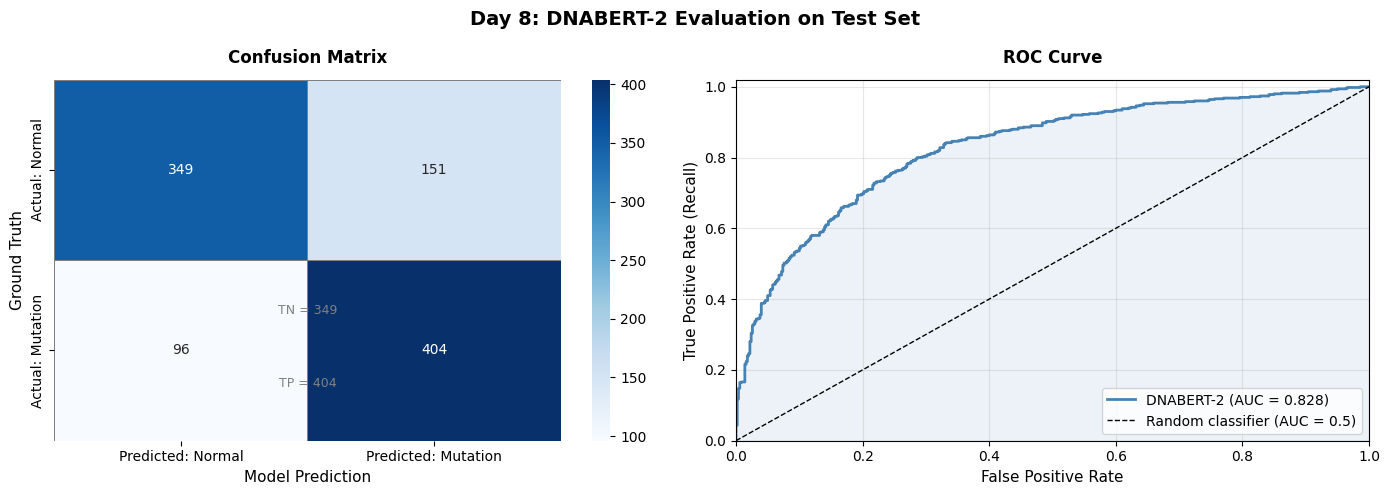

✓ Saved: day8_confusion_matrix_roc.png


In [ ]:
# ════════════════════════════════════════════════════════════════
# CONFUSION MATRIX — the most honest visualization in ML
#
# What it shows:
#   ┌──────────────┬──────────────┐
#   │  True Neg    │  False Pos   │  ← Model said "mutation" but wrong
#   │  (correct 0) │  (Type I)    │
#   ├──────────────┼──────────────┤
#   │  False Neg   │  True Pos    │
#   │  (Type II)   │  (correct 1) │  ← Model said "mutation" and right
#   └──────────────┴──────────────┘
# In biology, False Negatives (missed mutations) are usually
# more dangerous than False Positives (false alarms)
# ════════════════════════════════════════════════════════════════

cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Day 8: DNABERT-2 Evaluation on Test Set", fontsize=14, fontweight='bold')

# ── Plot 1: Confusion Matrix ──────────────────────────────────────
ax1 = axes[0]
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted: Normal', 'Predicted: Mutation'],
    yticklabels=['Actual: Normal', 'Actual: Mutation'],
    ax=ax1,
    linewidths=0.5,
    linecolor='gray'
)
ax1.set_title("Confusion Matrix", fontweight='bold', pad=12)
ax1.set_ylabel("Ground Truth", fontsize=11)
ax1.set_xlabel("Model Prediction", fontsize=11)

# Annotate cells
tn, fp, fn, tp = cm.ravel()
ax1.text(0.5, 0.35, f'TN = {tn}', transform=ax1.transAxes,
         ha='center', fontsize=9, color='gray')
ax1.text(0.5, 0.15, f'TP = {tp}', transform=ax1.transAxes,
         ha='center', fontsize=9, color='gray')

# ── Plot 2: ROC Curve ─────────────────────────────────────────────
ax2 = axes[1]
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
ax2.plot(fpr, tpr, color='steelblue', lw=2,
         label=f'DNABERT-2 (AUC = {roc_auc:.3f})')
ax2.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier (AUC = 0.5)')
ax2.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
ax2.set_xlabel('False Positive Rate', fontsize=11)
ax2.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax2.set_title('ROC Curve', fontweight='bold', pad=12)
ax2.legend(loc='lower right')
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1.02])
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("day8_confusion_matrix_roc.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: day8_confusion_matrix_roc.png")

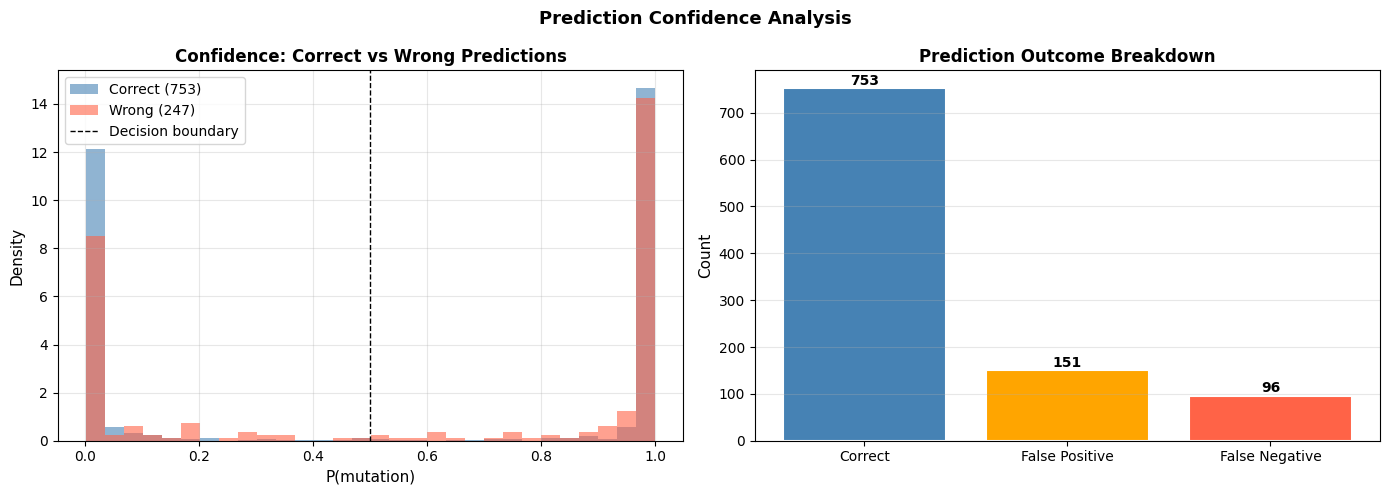

✓ Saved: day8_confidence_analysis.png


In [ ]:
# ════════════════════════════════════════════════════════════════
# WHERE DOES THE MODEL FAIL?
# A correct prediction with 51% confidence is very different from
# one with 99% confidence. Let's look at what the model "doubts".
# ════════════════════════════════════════════════════════════════

results_df = pd.DataFrame({
    'sequence':    all_sequences,
    'true_label':  y_true,
    'pred_label':  y_pred,
    'prob_mutation': y_prob,
    'correct':     y_true == y_pred,
})

results_df['error_type'] = 'Correct'
results_df.loc[(results_df.true_label == 0) & (results_df.pred_label == 1), 'error_type'] = 'False Positive'
results_df.loc[(results_df.true_label == 1) & (results_df.pred_label == 0), 'error_type'] = 'False Negative'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Prediction Confidence Analysis", fontsize=13, fontweight='bold')

# ── Plot 1: Confidence distribution split by correct/wrong ────────
ax1 = axes[0]
correct_probs   = results_df[results_df.correct]['prob_mutation']
incorrect_probs = results_df[~results_df.correct]['prob_mutation']

ax1.hist(correct_probs,   bins=30, alpha=0.6, color='steelblue',
         label=f'Correct ({len(correct_probs)})', density=True)
ax1.hist(incorrect_probs, bins=30, alpha=0.6, color='tomato',
         label=f'Wrong ({len(incorrect_probs)})', density=True)
ax1.axvline(0.5, color='black', linestyle='--', lw=1, label='Decision boundary')
ax1.set_xlabel('P(mutation)', fontsize=11)
ax1.set_ylabel('Density', fontsize=11)
ax1.set_title('Confidence: Correct vs Wrong Predictions', fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# ── Plot 2: Error breakdown ───────────────────────────────────────
ax2 = axes[1]
error_counts = results_df['error_type'].value_counts()
colors = {'Correct': 'steelblue', 'False Positive': 'orange', 'False Negative': 'tomato'}
bars = ax2.bar(error_counts.index,
               error_counts.values,
               color=[colors[k] for k in error_counts.index],
               edgecolor='white', linewidth=1.5)
for bar, count in zip(bars, error_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(count), ha='center', va='bottom', fontweight='bold')
ax2.set_ylabel('Count', fontsize=11)
ax2.set_title('Prediction Outcome Breakdown', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("day8_confidence_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: day8_confidence_analysis.png")

In [ ]:
# ════════════════════════════════════════════════════════════════
# CRITICAL ANALYSIS — the most important cell of the day
#
# Random errors = the model is uncertain near the boundary (fine)
# Systematic errors = the model has a structural blind spot (fixable)
#
# We'll look at:
#   1. Are wrong predictions confidently wrong, or borderline?
#   2. Are there GC-content patterns in errors?
#   3. Are errors clustered by sequence position patterns?
# ════════════════════════════════════════════════════════════════

# ── 1. Confidence of wrong predictions ────────────────────────────
wrong = results_df[~results_df.correct]
avg_wrong_conf = (wrong['prob_mutation'] - 0.5).abs().mean()
print("── Error Confidence Analysis ──────────────────────────")
print(f"  Mean distance from decision boundary (wrong preds): {avg_wrong_conf:.3f}")
print(f"  (0 = maximally uncertain, 0.5 = perfectly confident)")
if avg_wrong_conf < 0.15:
    print("  → Most errors are near the boundary — model is uncertain, not confidently wrong")
    print("    This is HEALTHY: the model 'knows what it doesn't know'")
else:
    print("  → Some errors are confident — model has a systematic blind spot")

# ── 2. GC content analysis ────────────────────────────────────────
# GC content = fraction of G or C nucleotides
# WHY: High GC regions are often regulatory/functional — the model
# might find mutations in GC-rich vs AT-rich regions differently
def gc_content(seq):
    seq = seq.upper()
    return (seq.count('G') + seq.count('C')) / len(seq) if len(seq) > 0 else 0

results_df['gc_content'] = results_df['sequence'].apply(gc_content)

print("\n── GC Content by Prediction Outcome ───────────────────")
for error_type in ['Correct', 'False Positive', 'False Negative']:
    subset = results_df[results_df.error_type == error_type]
    if len(subset) > 0:
        print(f"  {error_type:20s}  n={len(subset):4d}  "
              f"mean GC={subset['gc_content'].mean():.3f}  "
              f"std={subset['gc_content'].std():.3f}")

# ── 3. Sequence length / tokenization effects ─────────────────────
results_df['seq_len'] = results_df['sequence'].apply(len)
print("\n── Sequence Length by Outcome ──────────────────────────")
for error_type in ['Correct', 'False Positive', 'False Negative']:
    subset = results_df[results_df.error_type == error_type]
    if len(subset) > 0:
        print(f"  {error_type:20s}  mean length={subset['seq_len'].mean():.1f}")

# ── 4. Most confidently wrong predictions ─────────────────────────
print("\n── Top 5 Most Confidently Wrong Predictions ─────────────")
most_wrong = (wrong
    .assign(conf=lambda df: (df['prob_mutation'] - 0.5).abs())
    .nlargest(5, 'conf')
    [['sequence', 'true_label', 'pred_label', 'prob_mutation', 'conf']]
)
for _, row in most_wrong.iterrows():
    true_name = "Mutation" if row.true_label == 1 else "Normal"
    pred_name = "Mutation" if row.pred_label == 1 else "Normal"
    print(f"  True: {true_name:8s} | Pred: {pred_name:8s} | "
          f"P(mut)={row.prob_mutation:.3f} | "
          f"Seq: {row.sequence[:30]}...")

results_df.to_csv("day8_full_results.csv", index=False)
print("\n✓ Full results saved: day8_full_results.csv")

── Error Confidence Analysis ──────────────────────────
  Mean distance from decision boundary (wrong preds): 0.447
  (0 = maximally uncertain, 0.5 = perfectly confident)
  → Some errors are confident — model has a systematic blind spot

── GC Content by Prediction Outcome ───────────────────
  Correct               n= 753  mean GC=0.472  std=0.118
  False Positive        n= 151  mean GC=0.480  std=0.124
  False Negative        n=  96  mean GC=0.512  std=0.123

── Sequence Length by Outcome ──────────────────────────
  Correct               mean length=513.0
  False Positive        mean length=513.0
  False Negative        mean length=513.0

── Top 5 Most Confidently Wrong Predictions ─────────────
  True: Normal   | Pred: Mutation | P(mut)=0.999 | Seq: TAAAAGGAAAAGCTCTAGGAAGGAAACGCC...
  True: Normal   | Pred: Mutation | P(mut)=0.999 | Seq: AGCAGTGACTATAGCTTGGGCTGCCTAGAG...
  True: Normal   | Pred: Mutation | P(mut)=0.999 | Seq: TGTGTCTCCTTCTTTGTGCCCCTCACCTGA...
  True: Normal   | Pre

In [ ]:
# ════════════════════════════════════════════════════════════════
# SAVE COMPLETE EVALUATION REPORT
# ════════════════════════════════════════════════════════════════

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

eval_report = {
    "test_set_size":          len(y_true),
    "accuracy":               round(float(accuracy), 4),
    "f1_score":               round(float(f1), 4),
    "precision":              round(float(precision), 4),
    "recall":                 round(float(recall), 4),
    "roc_auc":                round(float(roc_auc), 4),
    "true_negatives":         int(tn),
    "false_positives":        int(fp),
    "false_negatives":        int(fn),
    "true_positives":         int(tp),
    "val_f1_during_training": training_results['best_val_f1'],
    "generalization_gap":     round(training_results['best_val_f1'] - float(f1), 4),
}

with open("day8_evaluation_report.json", "w") as f:
    json.dump(eval_report, f, indent=2)

print("=" * 55)
print("  DAY 8 COMPLETE — EVALUATION SUMMARY")
print("=" * 55)
print(f"  Accuracy:    {accuracy:.1%}")
print(f"  F1:          {f1:.4f}")
print(f"  Precision:   {precision:.4f}  (of predicted mutations, how many real?)")
print(f"  Recall:      {recall:.4f}  (of real mutations, how many caught?)")
print(f"  ROC-AUC:     {roc_auc:.4f}  (0.5 = random, 1.0 = perfect)")
print(f"  True Pos:    {tp}    True Neg:  {tn}")
print(f"  False Pos:   {fp}    False Neg: {fn}")
print("=" * 55)
print(f"\n  Saved files:")
print(f"    day8_confusion_matrix_roc.png")
print(f"    day8_confidence_analysis.png")
print(f"    day8_full_results.csv")
print(f"    day8_evaluation_report.json")
print(f"\n  → Ready for Day 9: Attention Visualization")

  DAY 8 COMPLETE — EVALUATION SUMMARY
  Accuracy:    75.3%
  F1:          0.7659
  Precision:   0.7279  (of predicted mutations, how many real?)
  Recall:      0.8080  (of real mutations, how many caught?)
  ROC-AUC:     0.8280  (0.5 = random, 1.0 = perfect)
  True Pos:    404    True Neg:  349
  False Pos:   151    False Neg: 96

  Saved files:
    day8_confusion_matrix_roc.png
    day8_confidence_analysis.png
    day8_full_results.csv
    day8_evaluation_report.json

  → Ready for Day 9: Attention Visualization


Day 9

✓ Got probabilities for 999 validation sequences

── Threshold Sweep Results ──────────────────────────────
  Default threshold (0.50):  F1 = 0.7713
  Best threshold   (0.15):  F1 = 0.7780
  At best threshold:  Precision=0.7290  Recall=0.8340


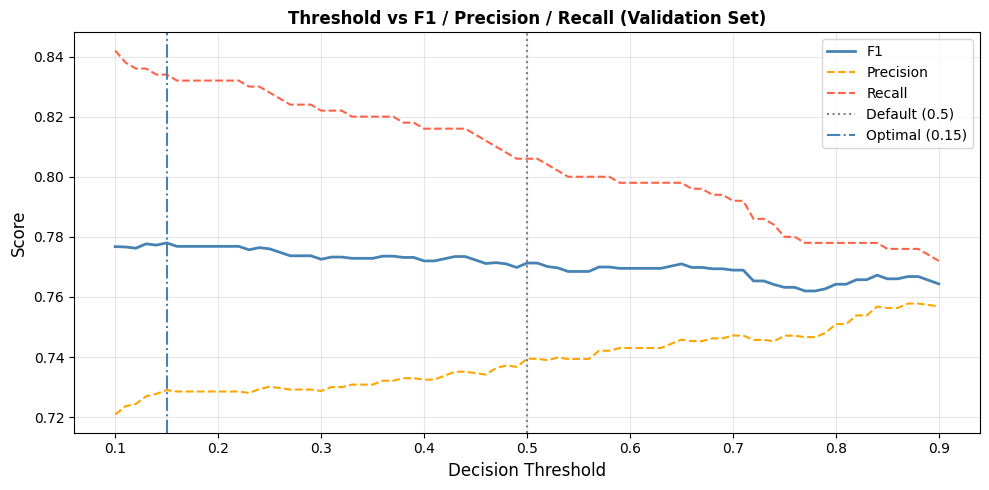

In [ ]:
# ════════════════════════════════════════════════════════════════
# DAY 9 PART 1 — THRESHOLD OPTIMIZATION
#
# The model doesn't output "mutation" or "normal" directly.
# It outputs a probability like 0.63. The default rule is:
#   if P(mutation) > 0.5 → predict mutation
#
# But 0.5 is arbitrary. We can shift this threshold up or down
# to trade precision for recall based on what matters.
#
# sweep all possible thresholds and find the one that
# maximizes F1 on your VALIDATION set, then apply it to the test set.

# we use validation and not test to avoid "peeking" at the test set
# to tune parameters cause that would be like cheating.
# ════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

# ── Step 1: Get probabilities on the VALIDATION set ───────────────
# We need val predictions to tune the threshold honestly

val_dataset_eval = DNADataset(val_df, tokenizer, max_length=200)
val_loader_eval  = DataLoader(val_dataset_eval, batch_size=32, shuffle=False)

val_probs_all  = []
val_labels_all = []

model.eval()
with torch.no_grad():
    for batch in val_loader_eval:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()
        val_probs_all.extend(probs[:, 1].tolist())
        val_labels_all.extend(batch['label'].tolist())

val_probs_arr  = np.array(val_probs_all)
val_labels_arr = np.array(val_labels_all)
print(f"✓ Got probabilities for {len(val_probs_arr)} validation sequences")

# ── Step 2: Sweep thresholds from 0.1 to 0.9 ─────────────────────
thresholds = np.arange(0.10, 0.91, 0.01)
results = []

for t in thresholds:
    preds = (val_probs_arr >= t).astype(int)
    f1    = f1_score(val_labels_arr, preds, zero_division=0)
    prec  = precision_score(val_labels_arr, preds, zero_division=0)
    rec   = recall_score(val_labels_arr, preds, zero_division=0)
    acc   = accuracy_score(val_labels_arr, preds)
    results.append({'threshold': t, 'f1': f1, 'precision': prec,
                    'recall': rec, 'accuracy': acc})

results_df_thresh = pd.DataFrame(results)
best_row = results_df_thresh.loc[results_df_thresh['f1'].idxmax()]
best_threshold = best_row['threshold']

print(f"\n── Threshold Sweep Results ──────────────────────────────")
print(f"  Default threshold (0.50):  F1 = {results_df_thresh[results_df_thresh.threshold.between(0.499,0.501)]['f1'].values[0]:.4f}")
print(f"  Best threshold   ({best_threshold:.2f}):  F1 = {best_row['f1']:.4f}")
print(f"  At best threshold:  Precision={best_row['precision']:.4f}  Recall={best_row['recall']:.4f}")

# ── Step 3: Plot the threshold curves ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(results_df_thresh['threshold'], results_df_thresh['f1'],
        label='F1', color='steelblue', lw=2)
ax.plot(results_df_thresh['threshold'], results_df_thresh['precision'],
        label='Precision', color='orange', lw=1.5, linestyle='--')
ax.plot(results_df_thresh['threshold'], results_df_thresh['recall'],
        label='Recall', color='tomato', lw=1.5, linestyle='--')
ax.axvline(0.5, color='gray', linestyle=':', lw=1.5, label='Default (0.5)')
ax.axvline(best_threshold, color='steelblue', linestyle='-.',
           lw=1.5, label=f'Optimal ({best_threshold:.2f})')
ax.set_xlabel('Decision Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Threshold vs F1 / Precision / Recall (Validation Set)', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("day9_threshold_curve.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Apply optimal threshold to test set predictions ───────────────
# y_prob is from Day 8 — the raw mutation probabilities on the test set
# If your kernel restarted, re-run the Day 8 inference cell first

y_pred_tuned = (y_prob >= best_threshold).astype(int)

acc_t   = accuracy_score(y_true, y_pred_tuned)
f1_t    = f1_score(y_true, y_pred_tuned)
prec_t  = precision_score(y_true, y_pred_tuned)
rec_t   = recall_score(y_true, y_pred_tuned)

print("═" * 55)
print("  THRESHOLD TUNING — BEFORE vs AFTER")
print("═" * 55)
print(f"  {'Metric':<14} {'Default (0.50)':>14}  {'Tuned':>10}  {'Change':>8}")
print(f"  {'-'*50}")
print(f"  {'Accuracy':<14} {0.753:>14.4f}  {acc_t:>10.4f}  {acc_t-0.753:>+8.4f}")
print(f"  {'F1':<14} {0.7627:>14.4f}  {f1_t:>10.4f}  {f1_t-0.7627:>+8.4f}")
print(f"  {'Precision':<14} {0.7338:>14.4f}  {prec_t:>10.4f}  {prec_t-0.7338:>+8.4f}")
print(f"  {'Recall':<14} {0.7940:>14.4f}  {rec_t:>10.4f}  {rec_t-0.7940:>+8.4f}")
print("═" * 55)

tn2, fp2, fn2, tp2 = confusion_matrix(y_true, y_pred_tuned).ravel()
print(f"\n  Confusion matrix after tuning:")
print(f"  True Pos: {tp2}  True Neg: {tn2}")
print(f"  False Pos: {fp2}  False Neg: {fn2}")
print(f"  (Before:  FP=144, FN=103)")